In [20]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"Could not find project root starting from {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
analysis_dir = PROJECT_ROOT / "analysis"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("analysis_dir :", analysis_dir)

PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
analysis_dir : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/analysis


In [21]:
def load_sweep(prefix: str) -> pd.DataFrame:
    """
    prefix: 'A4' or 'A5'
    loads any of these if present:
      analysis/noise_sweep_<prefix>_clip.csv
      analysis/noise_sweep_<prefix>_clip_pre_norm.csv
      analysis/noise_sweep_<prefix>_clip_pre_norm_noise_only.csv
      analysis/noise_sweep_<prefix>_clip_pre_norm_blur_only.csv
      analysis/noise_sweep_<prefix>_no_clip.csv
      analysis/noise_sweep_<prefix>.csv
    """
    paths = [
        analysis_dir / f"noise_sweep_{prefix}_clip.csv",
        analysis_dir / f"noise_sweep_{prefix}_clip_pre_norm.csv",
        analysis_dir / f"noise_sweep_{prefix}_clip_pre_norm_noise_only.csv",
        analysis_dir / f"noise_sweep_{prefix}_clip_pre_norm_blur_only.csv",
        analysis_dir / f"noise_sweep_{prefix}_no_clip.csv",
        analysis_dir / f"noise_sweep_{prefix}.csv",
    ]

    dfs = []
    for p in paths:
        if p.exists():
            print("Loading:", p.name)
            tmp = pd.read_csv(p)

            # IMPORTANT: your prenorm runs often store model="clip_pre_norm" inside the CSV,
            # so we override based on filename:
            if "clip_pre_norm_noise_only" in p.name:
                tmp["model"] = "clip_pre_norm_noise_only"
            elif "clip_pre_norm_blur_only" in p.name:
                tmp["model"] = "clip_pre_norm_blur_only"
            elif "clip_pre_norm" in p.name:
                tmp["model"] = "clip_pre_norm"
            # else keep whatever is already there (clip/convnext/vit)

            dfs.append(tmp)

    if not dfs:
        raise FileNotFoundError(f"No sweep CSVs found for {prefix} in {analysis_dir}")

    df = pd.concat(dfs, axis=0, ignore_index=True)

    # Nicer legend labels
    df["model"] = df["model"].replace({
        "clip": "CLIP (post-norm)",
        "clip_pre_norm": "CLIP (pre-norm: noise+blur)",
        "clip_pre_norm_noise_only": "CLIP (pre-norm: noise-only)",
        "clip_pre_norm_blur_only": "CLIP (pre-norm: blur-only)",
        "convnext": "ConvNeXt",
        "vit": "ViT",
    })

    # Deduplicate if overlapping exports exist
    if {"model", "level", "true_label"}.issubset(df.columns):
        df = df.drop_duplicates(subset=["model", "level", "true_label"]).reset_index(drop=True)

    return df

In [22]:
def plot_prob_fake(df: pd.DataFrame, title: str):
    plt.figure(figsize=(10, 5))
    for m in sorted(df["model"].unique()):
        d0 = df[(df["model"] == m) & (df["true_label"] == 0)].sort_values("level")
        d1 = df[(df["model"] == m) & (df["true_label"] == 1)].sort_values("level")

        plt.plot(d0["level"], d0["mean_prob_fake"], marker="o", label=f"{m}: IAM")
        plt.plot(d1["level"], d1["mean_prob_fake"], marker="o", label=f"{m}: Emuru")

    plt.xlabel("Noise level")
    plt.ylabel("Mean P(fake)")
    plt.title(title)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

def plot_accuracy(df: pd.DataFrame, title: str):
    acc_df = df.groupby(["model", "level"], as_index=False)["accuracy_overall"].mean()

    plt.figure(figsize=(8, 4))
    for m in sorted(acc_df["model"].unique()):
        d = acc_df[acc_df["model"] == m].sort_values("level")
        plt.plot(d["level"], d["accuracy_overall"] * 100, marker="o", label=m)

    plt.xlabel("Noise level")
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confidence(df: pd.DataFrame, title: str):
    dfc = df.copy()
    dfc["confidence"] = (dfc["mean_prob_fake"] - 0.5).abs()

    plt.figure(figsize=(10, 5))
    for m in sorted(dfc["model"].unique()):
        d0 = dfc[(dfc["model"] == m) & (dfc["true_label"] == 0)].sort_values("level")
        d1 = dfc[(dfc["model"] == m) & (dfc["true_label"] == 1)].sort_values("level")

        plt.plot(d0["level"], d0["confidence"], marker="o", label=f"{m}: IAM")
        plt.plot(d1["level"], d1["confidence"], marker="o", label=f"{m}: Emuru")

    plt.xlabel("Noise level")
    plt.ylabel("|P(fake) - 0.5| (confidence)")
    plt.title(title)
    plt.ylim(0, 0.5)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

Loading: noise_sweep_A4_clip.csv
Loading: noise_sweep_A4_no_clip.csv
A4 shape: (66, 9)
A4 models: ['CLIP (post-norm)', 'ConvNeXt', 'ViT']


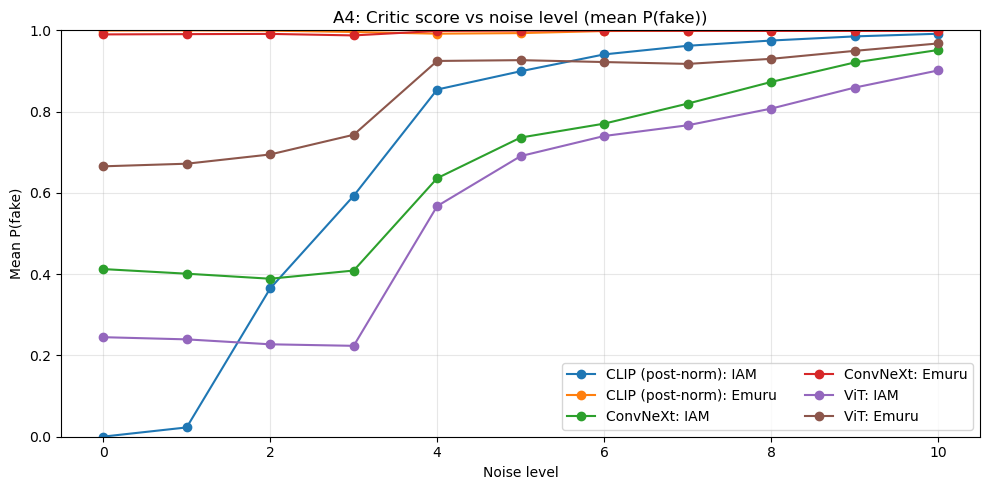

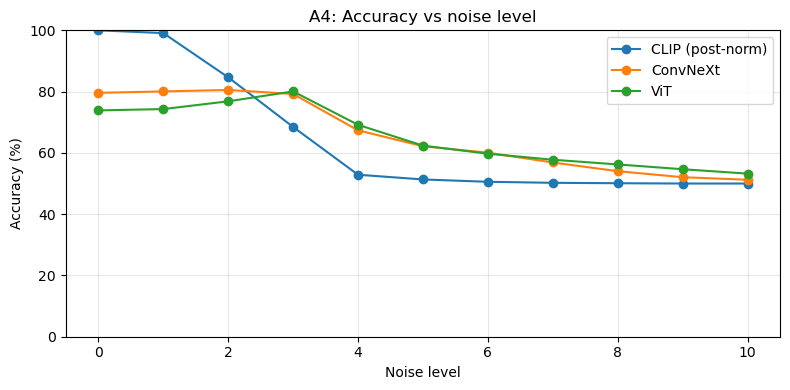

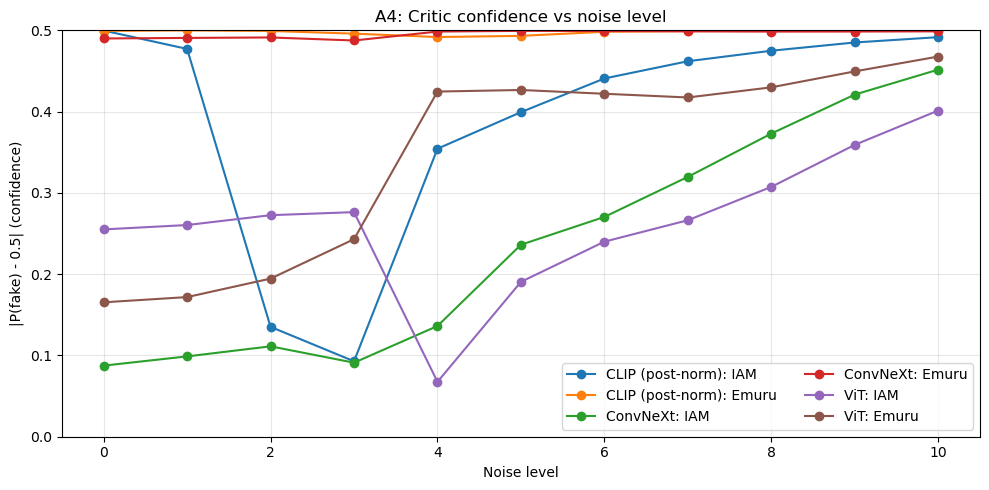

In [23]:
df_A4 = load_sweep("A4")
print("A4 shape:", df_A4.shape)
print("A4 models:", sorted(df_A4["model"].unique()))

plot_prob_fake(df_A4, "A4: Critic score vs noise level (mean P(fake))")
plot_accuracy(df_A4, "A4: Accuracy vs noise level")
plot_confidence(df_A4, "A4: Critic confidence vs noise level")

Loading: noise_sweep_A5_clip.csv
Loading: noise_sweep_A5_clip_pre_norm.csv
Loading: noise_sweep_A5_clip_pre_norm_noise_only.csv
Loading: noise_sweep_A5_clip_pre_norm_blur_only.csv
Loading: noise_sweep_A5_no_clip.csv
Loading: noise_sweep_A5.csv
A5 shape (clean): (66, 9)
A5 models (clean): ['CLIP (post-norm)', 'ConvNeXt', 'ViT']


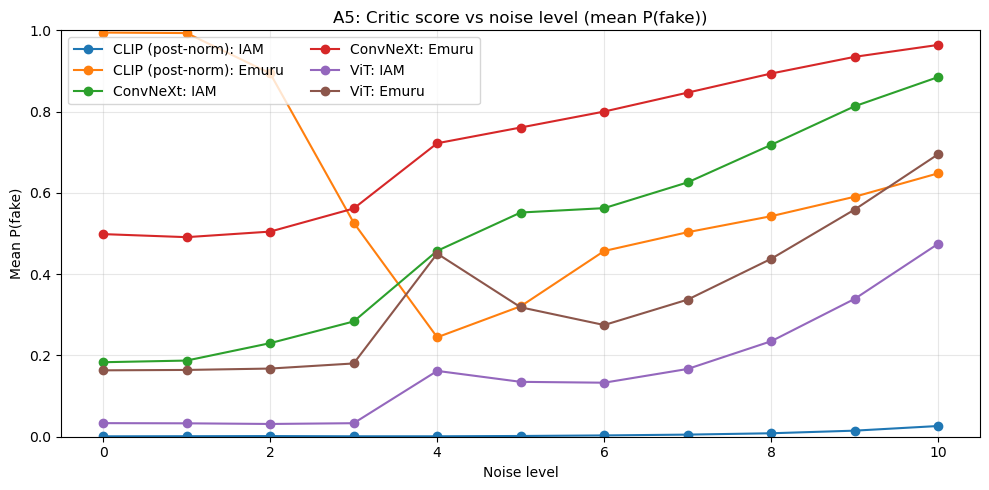

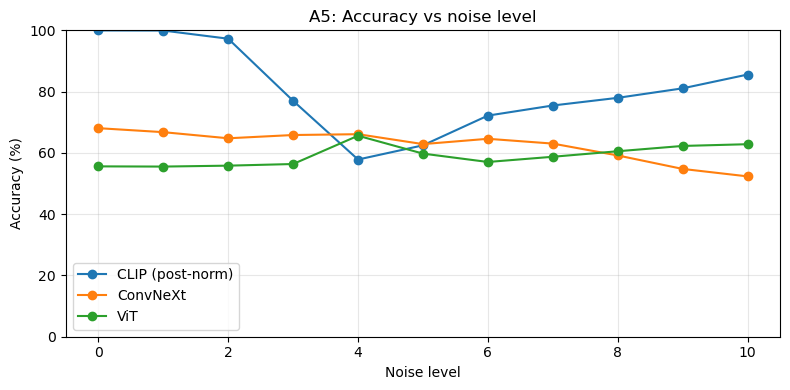

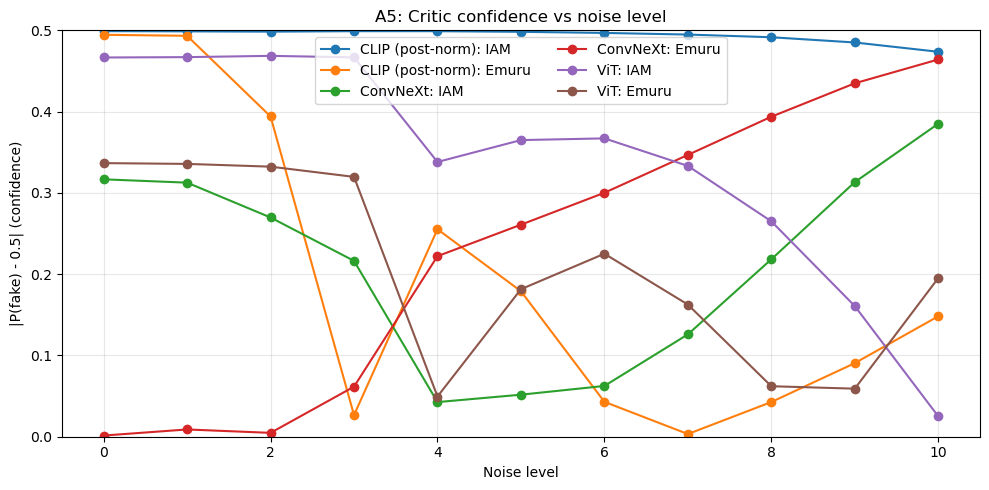

In [26]:
# ---- A5 (clean: only post-norm CLIP + ConvNeXt + ViT) ----
df_A5_all = load_sweep("A5")  # loads everything that exists

keep_models = ["CLIP (post-norm)", "ConvNeXt", "ViT"]
df_A5 = df_A5_all[df_A5_all["model"].isin(keep_models)].copy()

print("A5 shape (clean):", df_A5.shape)
print("A5 models (clean):", sorted(df_A5["model"].unique()))

plot_prob_fake(df_A5, "A5: Critic score vs noise level (mean P(fake))")
plot_accuracy(df_A5, "A5: Accuracy vs noise level")
plot_confidence(df_A5, "A5: Critic confidence vs noise level")

Loading: noise_sweep_A5_clip.csv
Loading: noise_sweep_A5_clip_pre_norm.csv
Loading: noise_sweep_A5_clip_pre_norm_noise_only.csv
Loading: noise_sweep_A5_clip_pre_norm_blur_only.csv
Loading: noise_sweep_A5_no_clip.csv
Loading: noise_sweep_A5.csv
A5 pre-norm shape: (66, 9)
A5 pre-norm models: ['CLIP (pre-norm: blur-only)', 'CLIP (pre-norm: noise+blur)', 'CLIP (pre-norm: noise-only)']


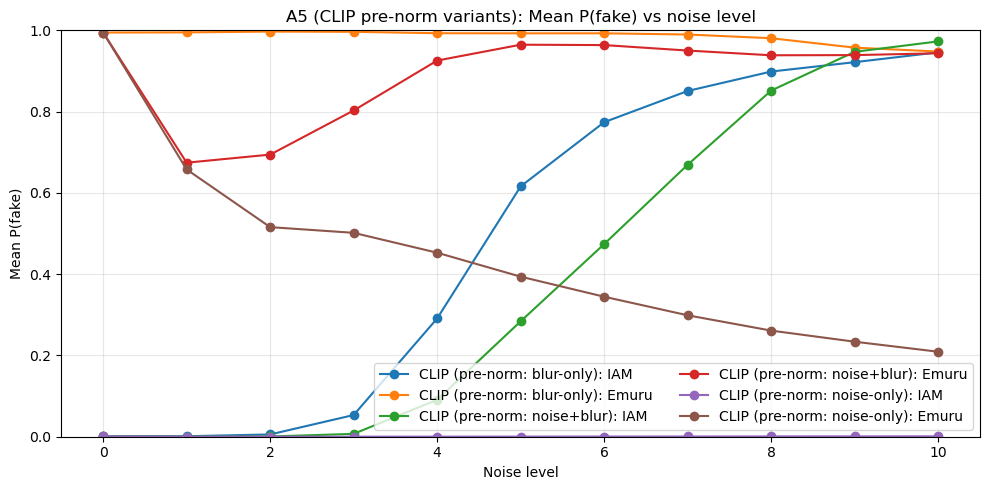

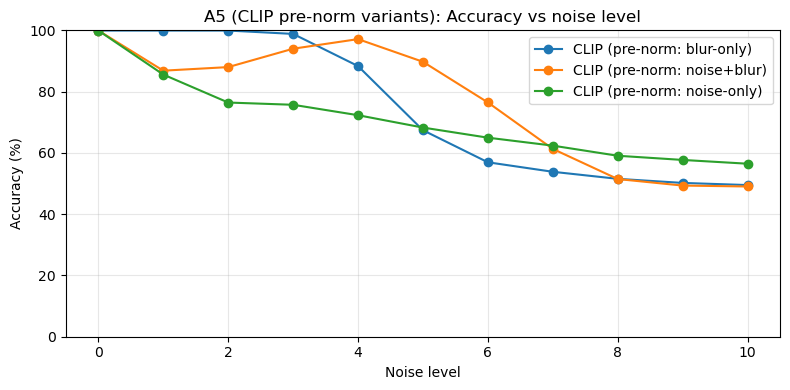

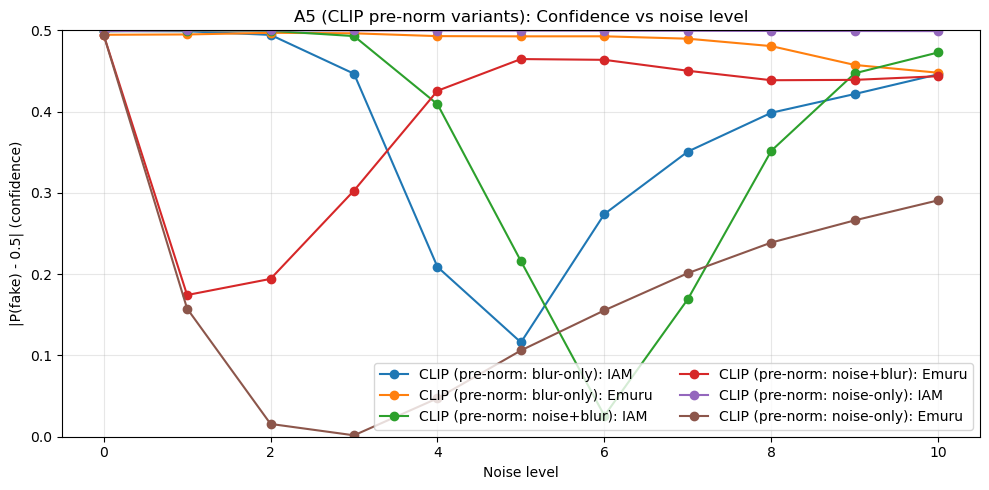

In [27]:
# ---- A5 (separate: ONLY CLIP pre-norm variants) ----
df_A5_all = load_sweep("A5")  # loads everything that exists

pre_norm_models = [
    "CLIP (pre-norm: noise+blur)",
    "CLIP (pre-norm: noise-only)",
    "CLIP (pre-norm: blur-only)",
]

df_A5_prenorm = df_A5_all[df_A5_all["model"].isin(pre_norm_models)].copy()

print("A5 pre-norm shape:", df_A5_prenorm.shape)
print("A5 pre-norm models:", sorted(df_A5_prenorm["model"].unique()))

plot_prob_fake(df_A5_prenorm, "A5 (CLIP pre-norm variants): Mean P(fake) vs noise level")
plot_accuracy(df_A5_prenorm, "A5 (CLIP pre-norm variants): Accuracy vs noise level")
plot_confidence(df_A5_prenorm, "A5 (CLIP pre-norm variants): Confidence vs noise level")

In [25]:
out_dir = analysis_dir / "figures"
out_dir.mkdir(exist_ok=True)

def save_current_fig(filename: str):
    path = out_dir / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path)

# Example:
# plot_accuracy(df_A5, "A5: Accuracy vs noise level")
# save_current_fig("A5_accuracy.png")